Objectives:
1. Using the UCI mushrooms dataset. Create a pandas DataFrame with a subset of the columns in the dataset. You should include the column that indicates edible or poisonous, the column that includes odor, and at least one other column of your choosing.
2. Add meaningful names for each column.
3. Replace the codes used in the data with numeric values—for example, in the first “target” column, “e” might become 0 and “p” might become 1. This is because your downstream processing in Project 4 using scikit-learn requires that values be stored as numerics.
4. Perform exploratory data analysis: show the distribution of data for each of the columns you selected, and show scatterplots for edible/poisonous vs. odor as well as the other column that you selected.
5. Include some text describing your preliminary conclusions about whether either of the other columns could be helpful in predicting if a specific mushroom is edible or poisonous.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


file_location = 'agaricus-lepiota.data'

# Create a list of column names and indexes taken from the dictionary on the UCI site
column_indexes = [0, 3, 5, 9]
column_names = ['poisonous', 'cap-color', 'odor', 'gill-color']


# import the data into a dataframe and throw an exception if there is an error
try:
    # use read_csv to import the data, set column names, inxexes, and set missing data to NaN
    mushrooms_df = pd.read_csv(file_location, header=None, usecols=column_indexes, names=column_names, na_values='?')
    # print df for verification
    print(mushrooms_df.head())

except FileNotFoundError:
    print(f"Error: The file '{file_location}' was not found.")

  poisonous cap-color odor gill-color
0         p         n    p          k
1         e         y    a          k
2         e         w    l          n
3         p         w    p          n
4         e         g    n          k


Map the data to numeric values that are supported by scikit-learn. 

Instances where the value is NaN == -1

poisonus: 
    p == 1, 
    e == 0
cap-color: 
    brown == n == 0, 
    buff == b == 1, 
    cinnamon == c == 2,
    gray == g == 3,
    green == r == 4, 
    pink == p == 5,
    purple == u == 6,
    red == e == 7,
    white == w == 8,
    yellow == y == 9
odor:
    almond == a == 0,
    anise == l == 1,
    creosote == c == 2,
    fishy == y == 3,
    foul == f == 4, 
    musty == m == 5,
    none == n == 6,
    pungent == p == 7,
    spicy == s == 8
gill-color:
    black == k == 0,
    brown == n == 1,
    buff == b == 2,
    chocolate == h == 3,
    gray == g == 4, 
    green == r == 5,
    orange == o == 6,
    pink == p == 7,
    purple == u == 8,
    red ==e == 9, 
    white ==w == 10,
    yellow ==y == 11



In [2]:
# Create a dictionary for lookups for each column

map_keys = {
    'poisonous': {
        'p': 1, 'e': 0
    },
    'cap-color': {
        'n': 0, 'b': 1, 'c': 2, 'g': 3, 'r': 4,
        'p': 5, 'u': 6, 'e': 7, 'w': 8, 'y': 9
    },
    'odor': {
        'a': 0, 'l': 1, 'c': 2, 'y': 3, 'f': 4, 
        'm': 5, 'n': 6, 'p': 7, 's': 8
    },
    'gill-color': {
        'k': 0, 'n': 1, 'b': 2, 'h': 3, 'g': 4, 
        'r': 5, 'o': 6, 'p': 7, 'u': 8, 'e': 9, 
        'w': 10, 'y': 11
    }
}

# Iterate through the dataframe to convert to numeric values
for col, map_key in map_keys.items():
        mushrooms_df[col] = mushrooms_df[col].map(map_key)

# Convert any NaN values to -1
mushrooms_df = mushrooms_df.fillna(-1).astype(int)

# print df to validate
print(mushrooms_df.head())

   poisonous  cap-color  odor  gill-color
0          1          0     7           0
1          0          9     0           0
2          0          8     1           1
3          1          8     7           1
4          0          3     6           0


Creating the visualizations:

1. Create a dictionary to translate numerical values into labels for graphing. 
2. Plot the distribution for the data in the mushrooms dataset.
3. Plot a scatter plot of odor vs poisonus with jitter added for visibility. 
4. Plot a Categorical Count Plot for Poisonous/Edible against Cap-Color, Gill-Color, and Odor.

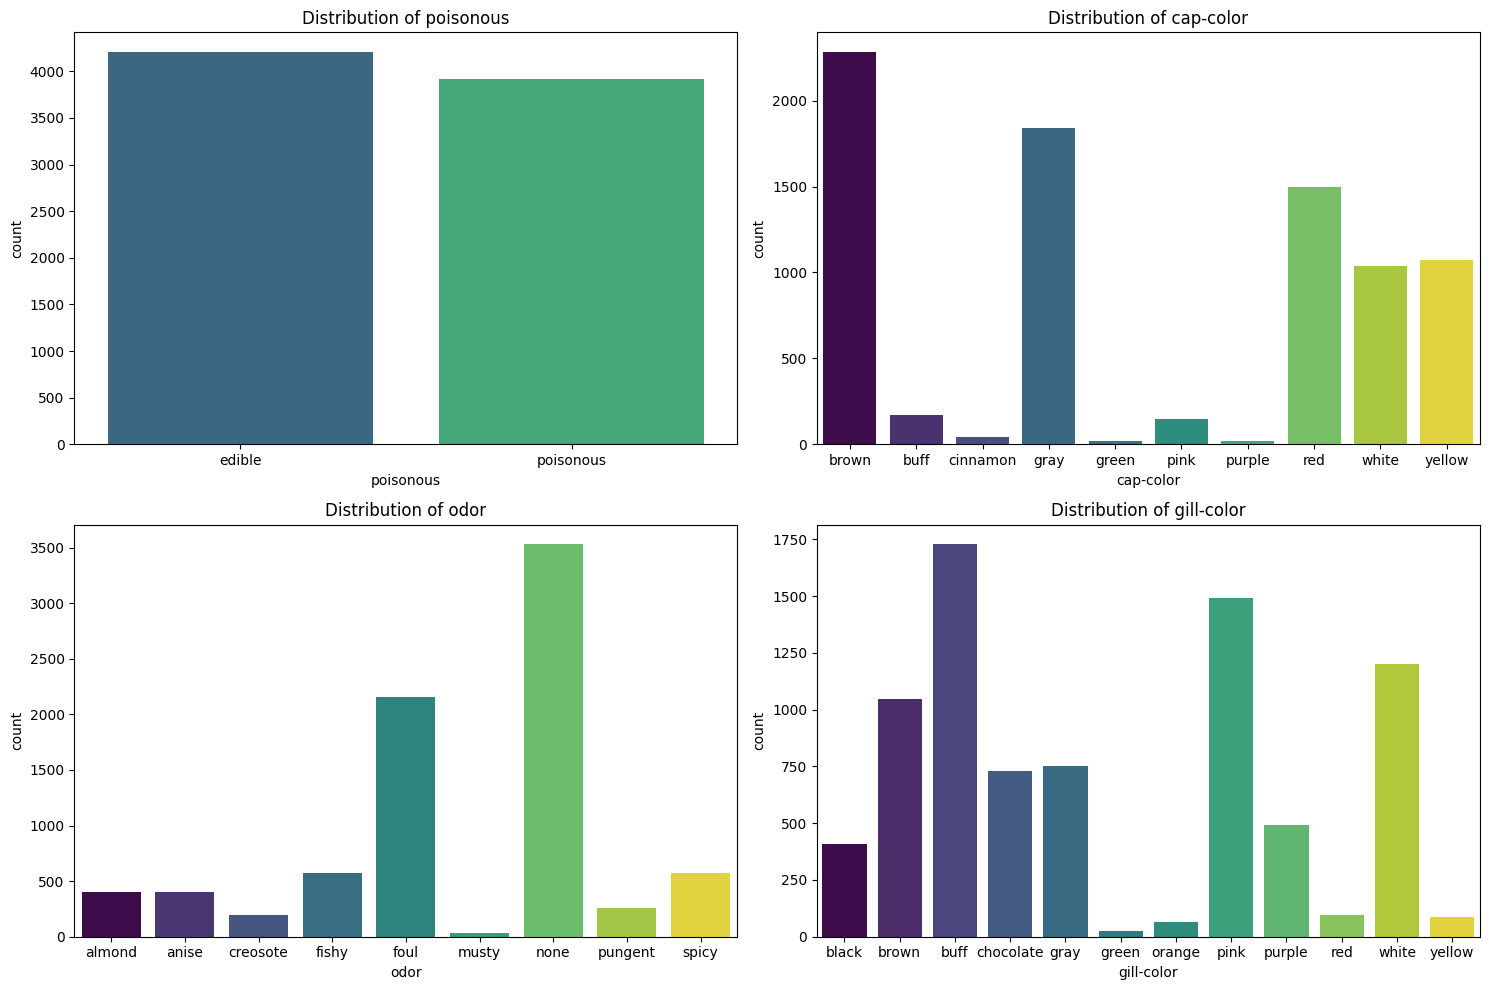

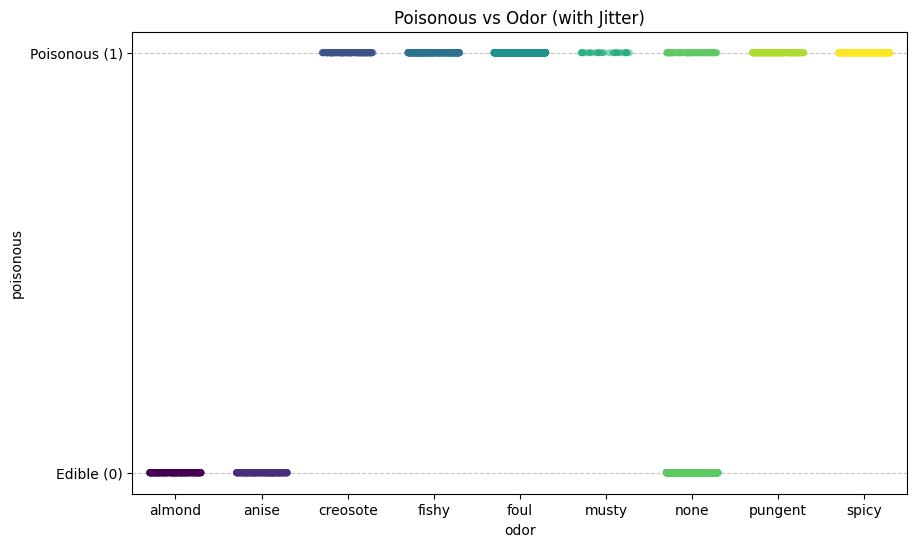

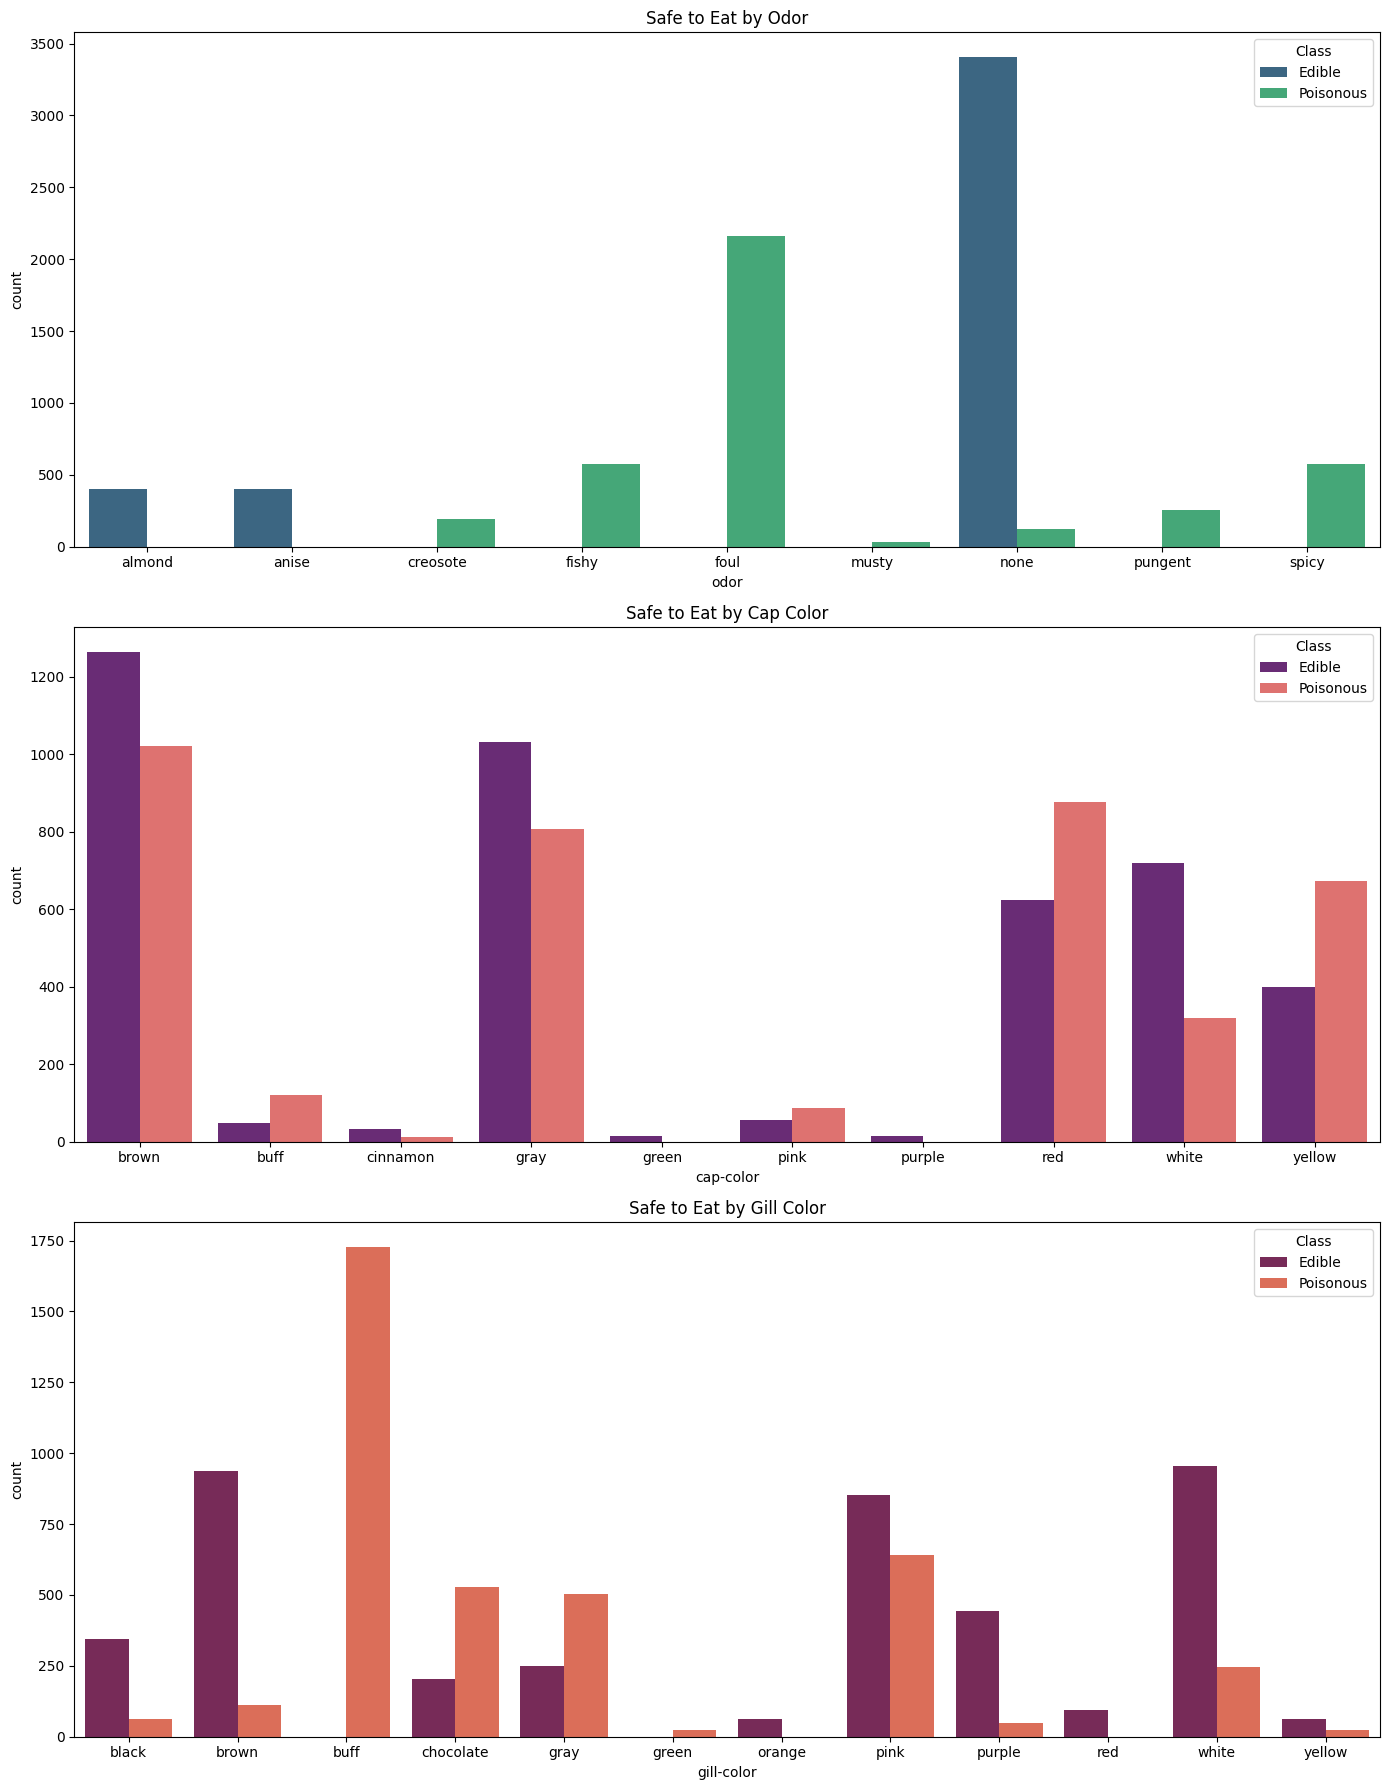

In [ ]:
# dictionary for labels 
display_labels = {
    'poisonous': {0: 'edible', 1: 'poisonous', -1: 'missing'},
    'cap-color': {0: 'brown', 1: 'buff', 2: 'cinnamon', 3: 'gray', 4: 'green', 5: 'pink', 6: 'purple', 7: 'red', 8: 'white', 9: 'yellow', -1: 'missing'},
    'odor':      {0: 'almond', 1: 'anise', 2: 'creosote', 3: 'fishy', 4: 'foul', 5: 'musty', 6: 'none', 7: 'pungent', 8: 'spicy', -1: 'missing'},
    'gill-color':{0: 'black', 1: 'brown', 2: 'buff', 3: 'chocolate', 4: 'gray', 5: 'green', 6: 'orange', 7: 'pink', 8: 'purple', 9: 'red', 10: 'white', 11: 'yellow', -1: 'missing'}
}

try:
    plt.figure(figsize=(15, 10))
    # Plot the distribution for each column in the mushroom data
    for i, col in enumerate(column_names):
        plt_instance = plt.subplot(2, 2, i + 1)
        sns.countplot(x=col, data=mushrooms_df, palette='viridis', hue=col, legend=False)
        plt.title(f'Distribution of {col}')
        unique_vals = sorted(mushrooms_df[col].unique())
        
        # add labels
        plt_instance.set_xticks(range(len(unique_vals)))
        plt_instance.set_xticklabels([display_labels[col][v] for v in unique_vals])
    plt.tight_layout()
    plt.savefig('distributions.png')

    # Create a scatter plot of the odor data relative to poisonous/edible
    plt.figure(figsize=(10, 6))
    shroom_scatter = sns.stripplot(x='odor', y='poisonous', data=mushrooms_df, jitter=0.3, alpha=0.5, palette='viridis', hue='odor', legend=False)
    # add jitter to make overlapping data points more visible
    plt.title('Poisonous vs Odor (with Jitter)')

    # Add axis labels
    plt.yticks(ticks=[0, 1], labels=['Edible (0)', 'Poisonous (1)'])
    unique_odor = sorted(mushrooms_df['odor'].unique())
    shroom_scatter.set_xticks(range(len(unique_odor)))
    shroom_scatter.set_xticklabels([display_labels['odor'][v] for v in unique_odor])

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.savefig('scatterplot.png')
    plt.show()

    # Create Categorical Count Plots
    plt.figure(figsize=(14, 18))
    # Plot Poisonous vs Odor
    plt.subplot(3, 1, 1)
    ccc_by_odor = sns.countplot(x='odor', hue='poisonous', data=mushrooms_df, palette='viridis')
    plt.title('Safe to Eat by Odor')
    unique_odor = sorted(mushrooms_df['odor'].unique())
    ccc_by_odor.set_xticks(range(len(unique_odor)))
    ccc_by_odor.set_xticklabels([display_labels['odor'][v] for v in unique_odor])
    ccc_by_odor.legend(title='Class', labels=['Edible', 'Poisonous'])

    # Plot Poisonous vs Cap-Color
    plt.subplot(3, 1, 2)
    ccc_by_cap_color = sns.countplot(x='cap-color', hue='poisonous', data=mushrooms_df, palette='magma')
    plt.title('Safe to Eat by Cap Color')
    unique_cap = sorted(mushrooms_df['cap-color'].unique())
    ccc_by_cap_color.set_xticks(range(len(unique_cap)))
    ccc_by_cap_color.set_xticklabels([display_labels['cap-color'][v] for v in unique_cap])
    ccc_by_cap_color.legend(title='Class', labels=['Edible', 'Poisonous'])

    # Plot Poisonous vs Gill-Color
    plt.subplot(3, 1, 3)
    ccc_by_gill_color = sns.countplot(x='gill-color', hue='poisonous', data=mushrooms_df, palette='rocket')
    plt.title('Safe to Eat by Gill Color')
    unique_gill = sorted(mushrooms_df['gill-color'].unique())
    ccc_by_gill_color.set_xticks(range(len(unique_gill)))
    ccc_by_gill_color.set_xticklabels([display_labels['gill-color'][v] for v in unique_gill])
    ccc_by_gill_color.legend(title='Class', labels=['Edible', 'Poisonous'])

    plt.tight_layout()
    plt.savefig('categorical_plot.png')
    plt.show()

except FileNotFoundError:
    print("Error: Dataset file not found.")

Conclusion:

Overall, the mushroom data is pretty evenly distributed between poisonous and edible mushrooms. I felt that using a Categorical Count Plot was a better way to visualize the relationship between poisonous mushrooms and the secondary characteristics: gill-color, cap-color, and odor. This is because there's much more risk associated with a mushroom being poisonous rather than edible. For instance, even though a vast majority of mushrooms with white gills are edible, the infamous deathcap mushroom also has white gills and could seriously make you ill if eaten. If you really trust your nose, then it is probably safe to eat a mushroom that smells like almonds or anise. 